In [ ]:
!pip install -q gdown inference-gpu supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 6.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 35.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.1/190.1 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.9/75.9 kB 7.4 

In [ ]:
!pip install -q git+https://github.com/roboflow/sports.git

  Preparing metadata (setup.py) ... done


In [ ]:
!gdown -O "0bfacc_0.mp4" "https://drive.google.com/uc?id=12TqauVZ9tLAv8kWxTTBFWtgt2hNQ4_ZF"
!gdown -O "2e57b9_0.mp4" "https://drive.google.com/uc?id=19PGw55V8aA6GZu5-Aac5_9mCy3fNxmEf"
!gdown -O "08fd33_0.mp4" "https://drive.google.com/uc?id=1OG8K6wqUw9t7lp9ms1M48DxRhwTYciK-"
!gdown -O "573e61_0.mp4" "https://drive.google.com/uc?id=1yYPKuXbHsCxqjA9G-S6aeR2Kcnos8RPU"
!gdown -O "121364_0.mp4" "https://drive.google.com/uc?id=1vVwjW1dE1drIdd4ZSILfbCGPD4weoNiu"

Downloading...
From: https://drive.google.com/uc?id=12TqauVZ9tLAv8kWxTTBFWtgt2hNQ4_ZF
To: /content/0bfacc_0.mp4
100% 19.9M/19.9M [00:00<00:00, 70.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=19PGw55V8aA6GZu5-Aac5_9mCy3fNxmEf
To: /content/2e57b9_0.mp4
100% 21.1M/21.1M [00:00<00:00, 33.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1OG8K6wqUw9t7lp9ms1M48DxRhwTYciK-
To: /content/08fd33_0.mp4
100% 19.9M/19.9M [00:00<00:00, 37.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1yYPKuXbHsCxqjA9G-S6aeR2Kcnos8RPU
To: /content/573e61_0.mp4
100% 18.9M/18.9M [00:00<00:00, 35.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1vVwjW1dE1drIdd4ZSILfbCGPD4weoNiu
To: /content/121364_0.mp4
100% 17.2M/17.2M [00:00<00:00, 70.1MB/s]


In [ ]:
import os
os.environ["ONNXRUNTIME_EXECUTION_PROVIDERS"]="[CUDAExecutionProvider]"

##Ball,players,goalkeepers and referees detection

In [ ]:
from inference import get_model
from google.colab import userdata

ROBOFLOW_API_KEY=userdata.get("ROBOFLOW_API_KEY")
PLAYER_DETECTION_MODEL_ID="football-players-detection-3zvbc/11"
PLAYER_DETECTION_MODEL=get_model(model_id=PLAYER_DETECTION_MODEL_ID,
                                 api_key=ROBOFLOW_API_KEY)

ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support SAM2 model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM2_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
ModelDependencyMissing: Your `inference` configuration does not support Gaze Detection model. Use pip install 'inference[gaze]' to install missing requirements.To suppress this warning, set CORE_MODEL_GAZE_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support GroundingDINO model. Use pip install 'inference[grounding-dino]' to install missing requirements.To suppress this warning, set CO

In [ ]:
import supervision as sv
from inference import get_model
from google.colab import userdata

def annotate_football_video(src_path:str,tar_path:str):

  ROBOFLOW_API_KEY=userdata.get("ROBOFLOW_API_KEY")
  PLAYER_DETECTION_MODEL_ID="football-players-detection-3zvbc/11"
  PLAYER_DETECTION_MODEL=get_model(model_id=PLAYER_DETECTION_MODEL_ID,
                                 api_key=ROBOFLOW_API_KEY)


  video_info=sv.VideoInfo.from_video_path(src_path)
  video_sink=sv.VideoSink(target_path=tar_path,video_info=video_info)
  frame_generator=sv.get_video_frames_generator(src_path)
  with video_sink:
    for frame in tqdm(frame_generator,total=video_info.total_frames):
      player_annotation=PLAYER_DETECTION_MODEL.infer(image=frame,confidence=0.3)[0]
      detections=sv.Detections.from_inference(player_annotation)

      labels=[
          f"{class_name} {confidence:.2f}"
          for class_name,confidence in zip(detections["class_name"],detections.confidence)
      ]
      annotated_frame=frame.copy()
      annotated_frame=sv.BoxAnnotator(color=sv.ColorPalette.from_hex(['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']),thickness=3).annotate(scene=annotated_frame)
      annotated_frame=sv.LabelAnnotator(color=sv.ColorPalette.from_hex(['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']),text_color=sv.Color.from_hex("#000000")).annotate(scene=annotated_frame)
      video_sink.write_frame(annotated_frame)


In [ ]:
import supervision as sv
from tqdm import tqdm

SOURCE_VIDEO_PATH="/content/08fd33_0.mp4"
TARGET_VIDEO_PATH="/content/08fd33_0_result_1.mp4"
BALL_ID=0

ellipse_annotator=sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']),
    thickness=3
    #base=20,height=17 #geometry of triangle in pixels
)

traingle_annotator=sv.TriangleAnnotator(
    color=sv.Color.from_hex("#FFD700"),#yellow color,
    base=20,height=17
)

box_annotator=sv.BoxAnnotator(
    color=sv.ColorPalette.from_hex(['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']),
    thickness=3
)

label_annotator=sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex("#000000")
)

video_info=sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_sink=sv.VideoSink(TARGET_VIDEO_PATH,video_info=video_info)
frame_generator=sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

with video_sink:
  for frame in tqdm(frame_generator,total=video_info.total_frames):

    result=PLAYER_DETECTION_MODEL.infer(frame,confidence=0.3)[0]
    detections=sv.Detections.from_inference(result)

    labels= [
      f"{class_name} {confidence:.2f}"
      for class_name,confidence in zip(detections["class_name"],detections.confidence)
    ]

    annotated_frame=frame.copy()
    annotated_frame=box_annotator.annotate(annotated_frame,detections)
    annotated_frame=label_annotator.annotate(annotated_frame,detections,labels=labels)
    video_sink.write_frame(annotated_frame)




100%|██████████| 750/750 [03:52<00:00,  3.23it/s]


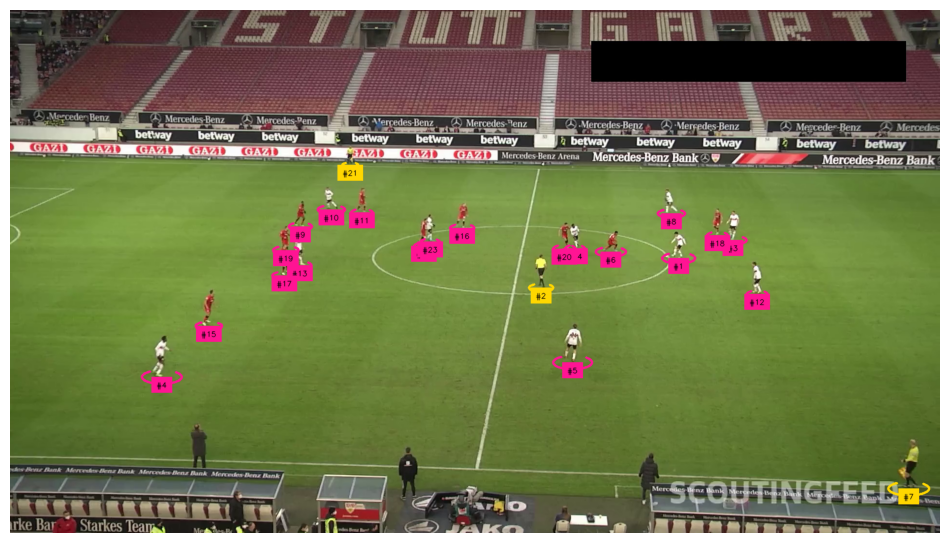

In [ ]:
import supervision as sv

SOURCE_VIDEO_PATH="/content/0bfacc_0.mp4"

ellipse_annotator=sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=3
)

label_annotator=sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex([ '#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex("#000000"),
    text_position=sv.Position.BOTTOM_CENTER
)

triangle_annotator=sv.TriangleAnnotator(
    color=sv.Color.from_hex("#FFD700"),
    base=20,height=17
)

tracker=sv.ByteTrack()  #tracker supported by supervision
tracker.reset()

frame_generator=sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame=next(frame_generator)

result=PLAYER_DETECTION_MODEL.infer(frame,confidence=0.3)[0]
detections=sv.Detections.from_inference(result)

#after parsing the detections we will divide them into two groups first group will be only detection ball class and second will be all other class
ball_detections=detections[detections.class_id==BALL_ID]
#supervision has a utility that allow us to expand the boxes to a specific number of pixel
ball_detections.xyxy=sv.pad_boxes(xyxy=ball_detections.xyxy,px=10)
all_detections=detections[detections.class_id!=BALL_ID]
all_detections=all_detections.with_nms(threshold=0.5,class_agnostic=True)
all_detections.class_id=all_detections.class_id-1
all_detections=tracker.update_with_detections(all_detections)

labels=[
    f"#{tracker_id}"
    for tracker_id
    in all_detections.tracker_id
]

annotated_frame=frame.copy()
annotated_frame=ellipse_annotator.annotate(annotated_frame,all_detections)
annotated_frame=triangle_annotator.annotate(annotated_frame,ball_detections)
annotated_frame=label_annotator.annotate(annotated_frame,all_detections,labels)

sv.plot_image(annotated_frame)


In theory dividing players into teams is simple we could run object detection model crop boxes containing players and then calculate average color of the pixels within the crop however this approach have few drawbacks:
1. The crop also includes background like grass, stands and even other players
2. The proportion of the pixels representing the player and the background in the crop varies depending on player's pose
3. Different illumination in different areas of pitch affect the average color value


Above points make this approach unreliable, it may work for some scenes but it will definately fail for some other scenes.

**Embeddings capture semantic meaning of an image making it robust in pose, occlusions or illumination changes**

We will use Siglip instead of clip refer to the paper titled as "Sigmoid Loss for Language Image Pre-Training"

In [ ]:
from tqdm import tqdm

PLAYER_ID=2
STRIDE=30 #we will be skipping every 29 frames and returning the 30th one
def extract_crops(source_video_path:str):
    frame_generator=sv.get_video_frames_generator(source_video_path,stride=STRIDE)

    crops=[]
    for frame in tqdm(frame_generator,desc="Collecting Crops"):
      result=PLAYER_DETECTION_MODEL.infer(frame,confidence=0.3)[0]
      detections=sv.Detections.from_inference(result)
      detections=detections.with_nms(threshold=0.5,class_agnostic=True)
      detections=detections[detections.class_id==PLAYER_ID]
      crops+=[
          sv.crop_image(frame,xyxy)
          for xyxy
          in detections.xyxy
      ]
    return crops


In [ ]:
crops=extract_crops(SOURCE_VIDEO_PATH)

In [ ]:
len(crops)

488

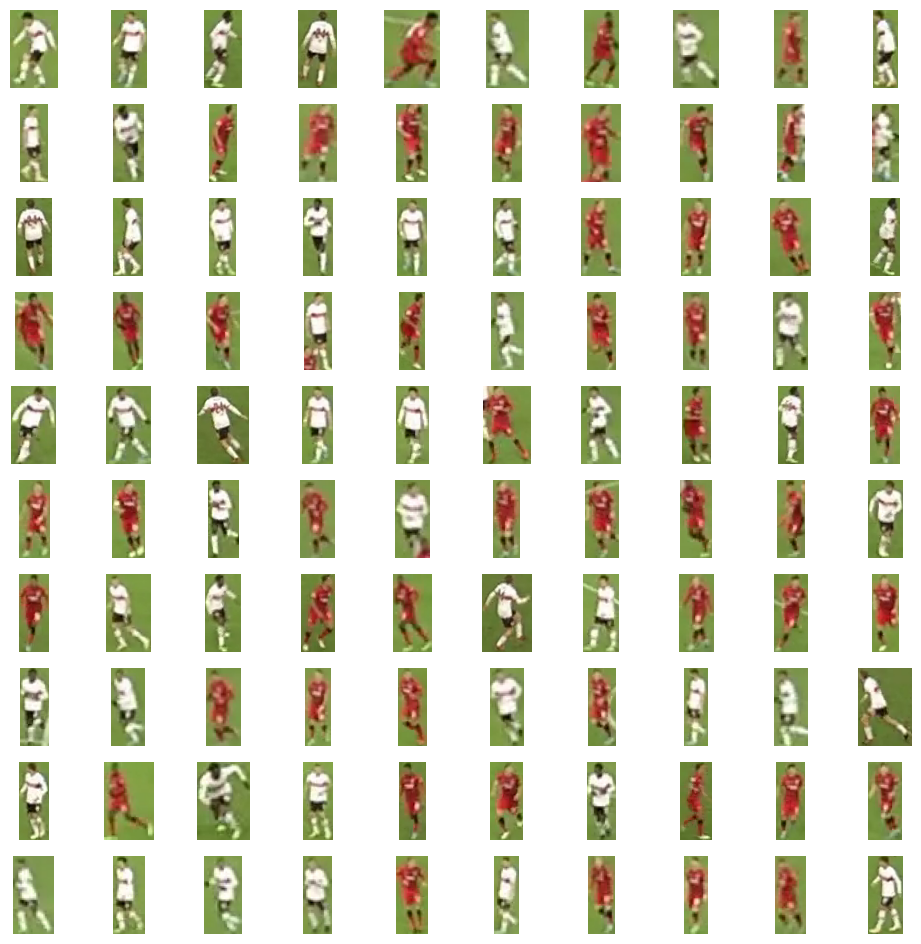

In [ ]:
sv.plot_images_grid(crops[:100],grid_size=(10,10))

In [ ]:
import torch
from transformers import AutoProcessor,SiglipVisionModel

SIGLIP_MODEL_PATH='google/siglip-base-patch16-224'
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
EMBEDDINGS_MODEL=SiglipVisionModel.from_pretrained(SIGLIP_MODEL_PATH).to(DEVICE)
EMBEDDINGS_PROCESSOR=AutoProcessor.from_pretrained(SIGLIP_MODEL_PATH)

The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

####supervision module is using opencv as base engine while siglip expect pillow format so we need to do necessary conversion

In [ ]:
import numpy as np
from more_itertools import chunked

BATCH_SIZE=32

# Remove invalid crops
crops = [c for c in crops if c is not None]

# Convert only if crop is numpy (OpenCV format)
crops = [
    sv.cv2_to_pillow(c) if isinstance(c, np.ndarray) else c
    for c in crops
]

batches=chunked(crops,BATCH_SIZE)
data=[]

with torch.no_grad():
  for batch in tqdm(batches,desc='embeddings extraction'):
    inputs=EMBEDDINGS_PROCESSOR(images=batch,return_tensors='pt').to(DEVICE) #processor is responsible for pre and post processing of the data
    outputs=EMBEDDINGS_MODEL(**inputs)
    embeddings=torch.mean(outputs.last_hidden_state, dim=1).cpu().numpy()
    data.append(embeddings)

data=np.concatenate(data)




embeddings extraction: 16it [00:06,  2.56it/s]


In [ ]:
data.shape

(488, 768)

In [ ]:
import umap
from sklearn.cluster import KMeans

REDUCER=umap.UMAP(n_components=3)
CLUSTERING_MODEL=KMeans(n_clusters=2)


In [ ]:
projections=REDUCER.fit_transform(data)


In [ ]:
projections.shape

(488, 3)

In [ ]:
clusters=CLUSTERING_MODEL.fit_predict(projections)

In [ ]:
clusters[:10]

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0], dtype=int32)

In [ ]:
team_0=[
    crop
    for crop,cluster
    in zip(crops,clusters)
    if cluster==0
]

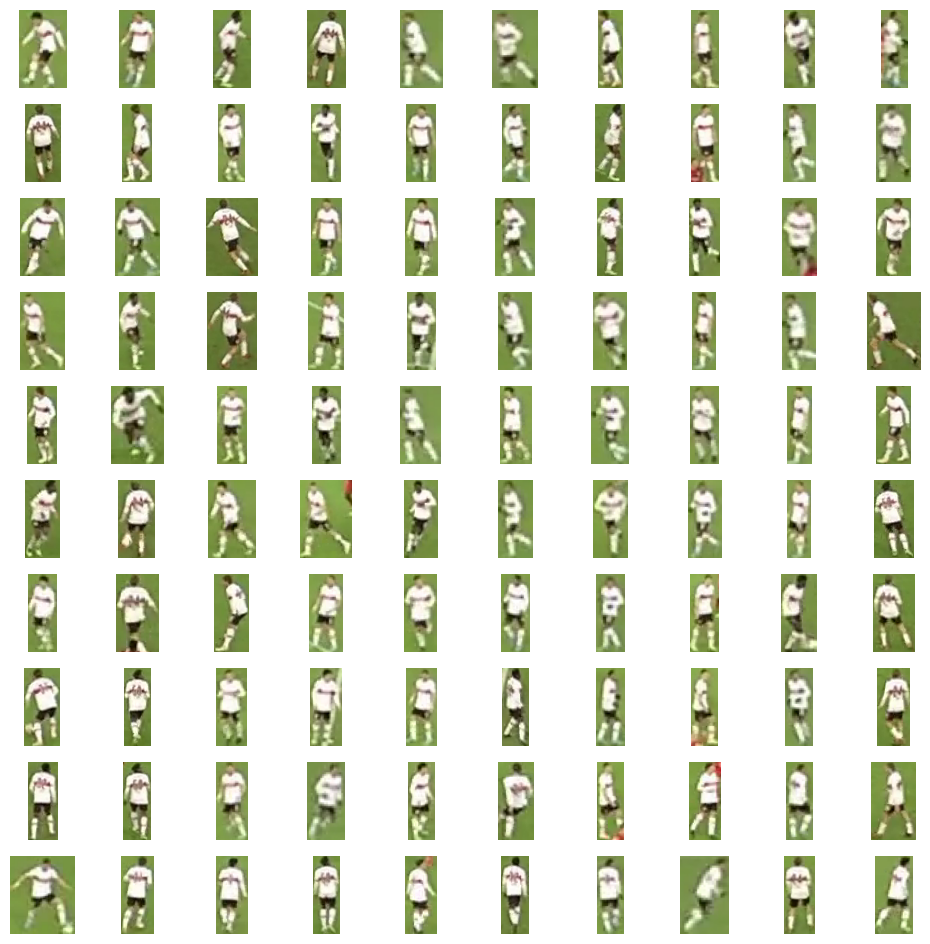

In [ ]:
sv.plot_images_grid(team_0[:100],grid_size=(10,10))

In [ ]:
def resolve_goalkeeper_team_id(players_detections:sv.Detections,
                               goalkeepers_detections:sv.Detections):
  goalkeepers_xy=goalkeepers_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
  players_xy=players_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)

  team_0_centroid=players_xy[players_detections.class_id==0].mean(axis=0)
  team_1_centroid=players_xy[players_detections.class_id==1].mean(axis=0)

  goalkeeper_team_ids=[]
  for goalkeeper_xy in goalkeepers_xy:
    dist_0=np.linalg.norm(goalkeeper_xy-team_0_centroid)
    dist_1=np.linalg.norm(goalkeeper_xy-team_1_centroid)
    goalkeeper_team_ids.append(0 if dist_0< dist_1 else 1)

  return np.array(goalkeeper_team_ids)

Embedding extraction: 16it [00:06,  2.61it/s]
Embedding extraction: 1it [00:00,  3.93it/s]


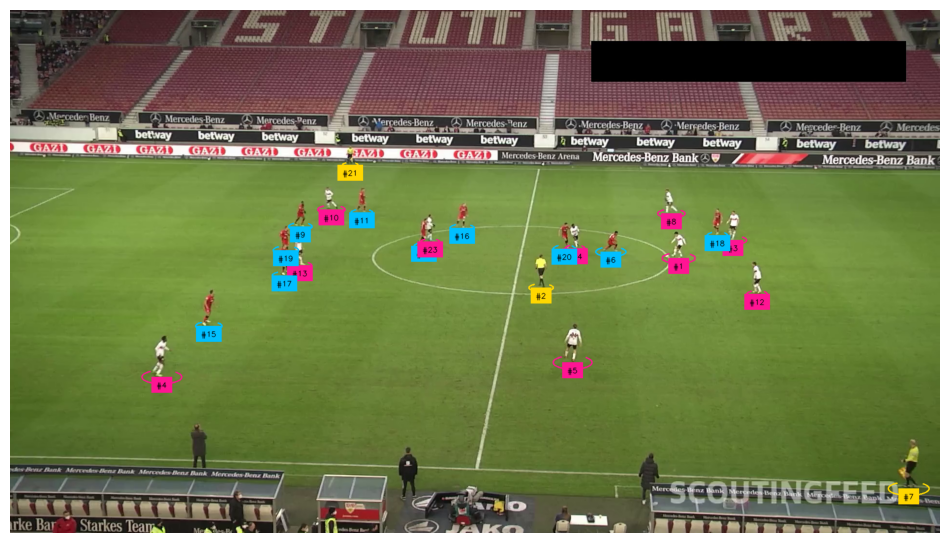

In [ ]:
import supervision as sv
from sports.common.team import TeamClassifier

SOURCE_VIDEO_PATH="/content/0bfacc_0.mp4"
BALL_ID=0
GOALKEEPER_ID=1
PLAYER_ID=2
REFEREE_ID=3

crops=extract_crops(SOURCE_VIDEO_PATH)
team_classifier=TeamClassifier(device=DEVICE)
team_classifier.fit(crops)

ellipse_annotator=sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)

label_annotator=sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex("#000000"),
    text_position=sv.Position.BOTTOM_CENTER
)

triangle_annotator=sv.TriangleAnnotator(
    color=sv.Color.from_hex("#FFD700"),
    base=20,height=17
)

tracker=sv.ByteTrack()
tracker.reset()

frame_generator=sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame=next(frame_generator)

result=PLAYER_DETECTION_MODEL.infer(frame,confidence=0.3)[0]
detections=sv.Detections.from_inference(result)

ball_detections=detections[detections.class_id==BALL_ID]
# ball_detections=tracker.update_with_detections(all_detections) #a yellowish triangle appear on the head of each player
ball_detections.xyxy=sv.pad_boxes(xyxy=ball_detections.xyxy,px=10)

all_detections=detections[detections.class_id!=BALL_ID]
all_detections=all_detections.with_nms(threshold=0.5,class_agnostic=True)
all_detections=tracker.update_with_detections(all_detections)

players_detections=all_detections[all_detections.class_id==PLAYER_ID]
goalkeepers_detections=all_detections[all_detections.class_id==GOALKEEPER_ID]
referees_detections=all_detections[all_detections.class_id==REFEREE_ID]

players_crops=[sv.crop_image(frame,xyxy) for xyxy in players_detections.xyxy]
players_detections.class_id=team_classifier.predict(players_crops)

goalkeepers_detections.class_id=resolve_goalkeeper_team_id(players_detections,goalkeepers_detections)
referees_detections.class_id-=1

all_detections=sv.Detections.merge([players_detections,goalkeepers_detections,referees_detections])

labels=[
    f"#{tracker_id}"
    for tracker_id
    in all_detections.tracker_id
]


annotated_frame=frame.copy()
# Ensure class_id is int
all_detections.class_id = all_detections.class_id.astype(int)
ball_detections.class_id = ball_detections.class_id.astype(int)

annotated_frame=ellipse_annotator.annotate(annotated_frame,all_detections)
annotated_frame=triangle_annotator.annotate(annotated_frame,ball_detections)
annotated_frame=label_annotator.annotate(annotated_frame,all_detections,labels)
sv.plot_image(annotated_frame)

###PITCH KEYPOINT DETECTION

In [ ]:
PITCH_DETECTION_MODEL_ID="football-field-detection-f07vi/14"
PITCH_DETECTION_MODEL=get_model(PITCH_DETECTION_MODEL_ID,ROBOFLOW_API_KEY)

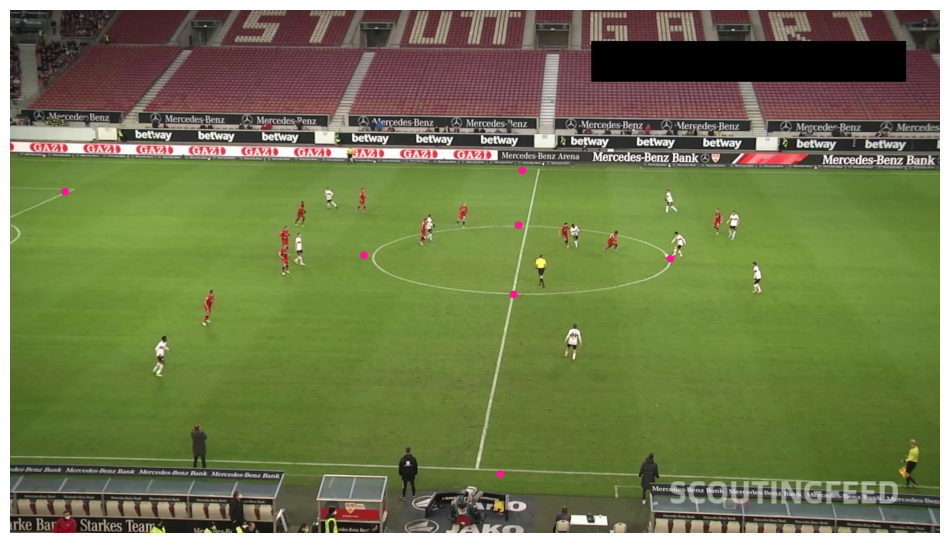

In [ ]:
vertex_annotator=sv.VertexAnnotator(
    color=sv.Color.from_hex("#FF1493"),
    radius=8
)

frame_generator=sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame=next(frame_generator)

result=PITCH_DETECTION_MODEL.infer(frame,confidence=0.3)[0]
key_points=sv.KeyPoints.from_inference(result)

filter=key_points.confidence[0]>0.5
frame_reference_points=key_points.xy[0][filter]
frame_reference_key_points=sv.KeyPoints(xy=frame_reference_points[np.newaxis,...])


annotated_frame=frame.copy()
annotated_frame=vertex_annotator.annotate(annotated_frame,frame_reference_key_points)

sv.plot_image(annotated_frame)

In [ ]:
key_points.confidence[0]

array([3.38356495e-02, 1.98495388e-03, 1.34110451e-04, 2.38418579e-07,
       2.38418579e-07, 4.76837158e-06, 1.39480829e-03, 2.14576721e-06,
       1.60509348e-03, 5.88706374e-01, 1.06794536e-01, 3.11946869e-03,
       1.94311142e-05, 9.99275386e-01, 9.99884129e-01, 9.99892712e-01,
       9.04064000e-01, 1.39109075e-01, 1.51730776e-02, 3.18050385e-04,
       4.41074371e-06, 1.98781490e-04, 1.40309334e-04, 3.57627869e-07,
       6.26087189e-03, 2.68995762e-04, 1.59740448e-05, 0.00000000e+00,
       1.19209290e-07, 1.34706497e-05, 9.98580694e-01, 9.98445094e-01],
      dtype=float32)

### project pitch lines on frame

In [ ]:
from sports.configs.soccer import SoccerPitchConfiguration

CONFIG=SoccerPitchConfiguration()

In [ ]:
CONFIG.vertices

[(0, 0),
 (0, 1450.0),
 (0, 2584.0),
 (0, 4416.0),
 (0, 5550.0),
 (0, 7000),
 (550, 2584.0),
 (550, 4416.0),
 (1100, 3500.0),
 (2015, 1450.0),
 (2015, 2584.0),
 (2015, 4416.0),
 (2015, 5550.0),
 (6000.0, 0),
 (6000.0, 2585.0),
 (6000.0, 4415.0),
 (6000.0, 7000),
 (9985, 1450.0),
 (9985, 2584.0),
 (9985, 4416.0),
 (9985, 5550.0),
 (10900, 3500.0),
 (11450, 2584.0),
 (11450, 4416.0),
 (12000, 0),
 (12000, 1450.0),
 (12000, 2584.0),
 (12000, 4416.0),
 (12000, 5550.0),
 (12000, 7000),
 (5085.0, 3500.0),
 (6915.0, 3500.0)]

In [ ]:
CONFIG.edges

[(1, 2),
 (2, 3),
 (3, 4),
 (4, 5),
 (5, 6),
 (7, 8),
 (10, 11),
 (11, 12),
 (12, 13),
 (14, 15),
 (15, 16),
 (16, 17),
 (18, 19),
 (19, 20),
 (20, 21),
 (23, 24),
 (25, 26),
 (26, 27),
 (27, 28),
 (28, 29),
 (29, 30),
 (1, 14),
 (2, 10),
 (3, 7),
 (4, 8),
 (5, 13),
 (6, 17),
 (14, 25),
 (18, 26),
 (23, 27),
 (24, 28),
 (21, 29),
 (17, 30)]

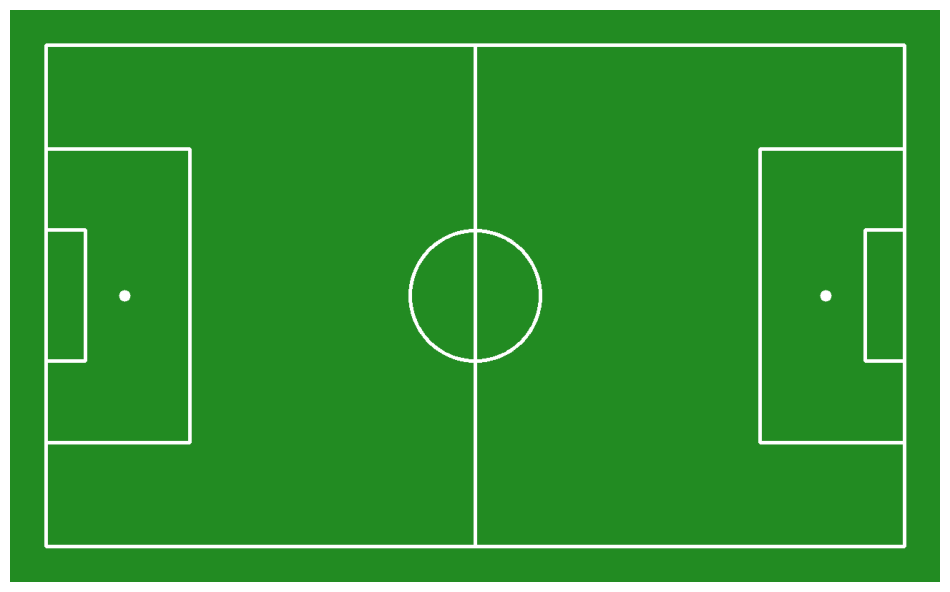

In [ ]:
from sports.annotators.soccer import draw_pitch

annotated_frame=draw_pitch(CONFIG)
sv.plot_image(annotated_frame)

In [ ]:
# import cv2

# class ViewTransformer:
#     def __init__(self, source: np.ndarray, target: np.ndarray):
#         source = source.astype(np.float32)
#         target = target.astype(np.float32)

#         # check shape and number of points
#         if source.shape[0] < 4 or target.shape[0] < 4:
#             raise ValueError(
#                 f"Need at least 4 corresponding points, got {source.shape[0]} and {target.shape[0]}"
#             )

#         self.m, _ = cv2.findHomography(source, target)
#         if self.m is None:
#             raise ValueError("Homography could not be computed — invalid or degenerate point pairs.")
#-------------------------------------------------------------------------------------------------
# class ViewTransformer: (custom and working reasonably well)

#   def __init__(self,source:np.ndarray,target:np.ndarray):
#     source=source.astype(np.float32)
#     target=target.astype(np.float32)
#     self.m,_=cv2.findHomography(source,target)

#   def transform_points(self, points:np.ndarray)-> np.ndarray:
#     points=points.reshape(-1,1,2).astype(np.float32)
#     points=cv2.perspectiveTransform(points,self.m)
#     return points.reshape(-1,2).astype(np.float32)

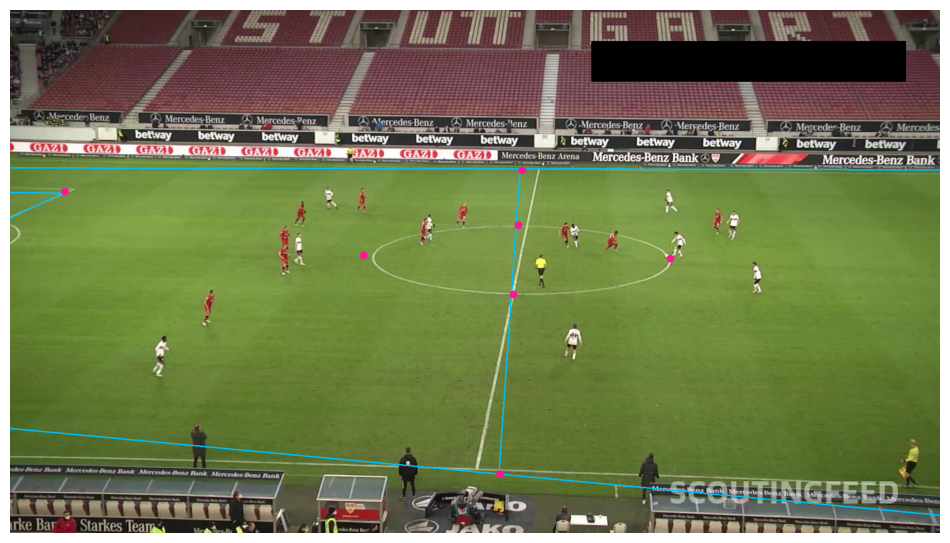

In [ ]:
import cv2
from sports.common.view import ViewTransformer

vertex_annotator=sv.VertexAnnotator(
    color=sv.Color.from_hex("#FF1493"),
    radius=8
)

vertex_annotator_2=sv.VertexAnnotator(
    color=sv.Color.from_hex("#00BFFF"),
    radius=8
)

edge_annotator=sv.EdgeAnnotator(
    color=sv.Color.from_hex("#00BFFF"),
    thickness=2,
    edges=CONFIG.edges
)

frame_generator=sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame=next(frame_generator)

result=PITCH_DETECTION_MODEL.infer(frame,confidence=0.3)[0]
key_points=sv.KeyPoints.from_inference(result)

filter=key_points.confidence[0]>0.5
frame_reference_points=key_points.xy[0][filter]
frame_reference_key_points=sv.KeyPoints(xy=frame_reference_points[np.newaxis,...])

pitch_reference_points=np.array(CONFIG.vertices)[filter]

view_transformer=ViewTransformer(
    source=pitch_reference_points,
    target=frame_reference_points
)

pitch_all_points=np.array(CONFIG.vertices)
frame_all_points=view_transformer.transform_points(pitch_all_points)

frame_all_key_points=sv.KeyPoints(xy=frame_all_points[np.newaxis,...])

annotated_frame=frame.copy()
annotated_frame=edge_annotator.annotate(annotated_frame,frame_all_key_points)
annotated_frame=vertex_annotator.annotate(annotated_frame,frame_reference_key_points)

sv.plot_image(annotated_frame)

#pitch to camera

###performing transformation in other direction (from camera to pitch)

In [ ]:
import supervision as sv
from tqdm import tqdm
from sports.common.team import TeamClassifier

SOURCE_VIDEO_PATH+SOURCE_VIDEO_PATH


'/content/0bfacc_0.mp4/content/0bfacc_0.mp4'

Embedding extraction: 16it [00:06,  2.51it/s]
Embedding extraction: 1it [00:00,  4.08it/s]


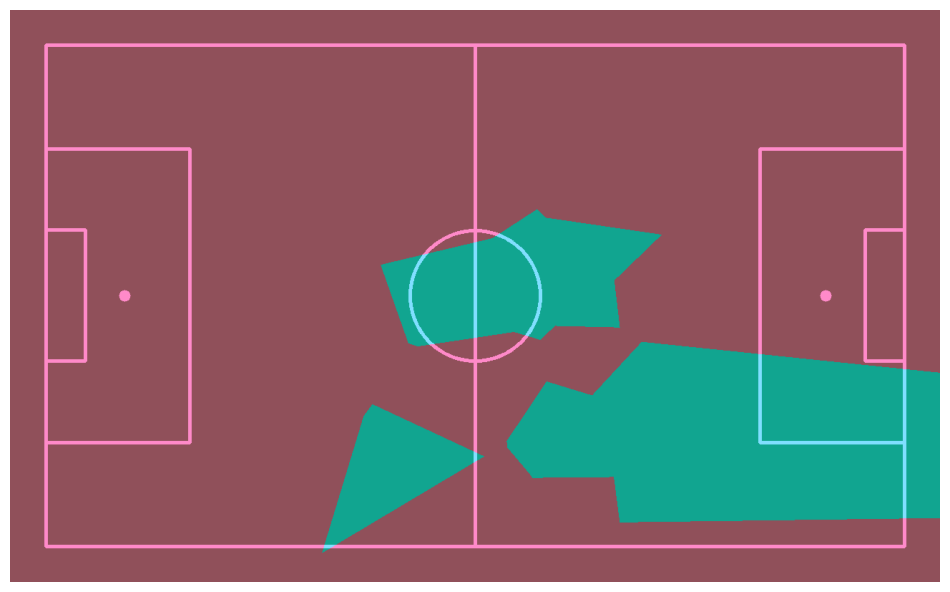

In [ ]:
import supervision as sv
from sports.common.team import TeamClassifier
from sports.annotators.soccer import draw_pitch,draw_points_on_pitch,draw_pitch_voronoi_diagram

SOURCE_VIDEO_PATH="/content/08fd33_0.mp4"
BALL_ID=0
GOALKEEPER_ID=1
PLAYER_ID=2
REFEREE_ID=3

crops=extract_crops(SOURCE_VIDEO_PATH)
team_classifier=TeamClassifier(device=DEVICE)
team_classifier.fit(crops)


tracker=sv.ByteTrack()
tracker.reset()

frame_generator=sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame=next(frame_generator)

result=PLAYER_DETECTION_MODEL.infer(frame,confidence=0.3)[0]
detections=sv.Detections.from_inference(result)

ball_detections=detections[detections.class_id==BALL_ID]
# ball_detections=tracker.update_with_detections(all_detections) #a yellowish triangle appear on the head of each player
ball_detections.xyxy=sv.pad_boxes(xyxy=ball_detections.xyxy,px=10)

all_detections=detections[detections.class_id!=BALL_ID]
all_detections=all_detections.with_nms(threshold=0.5,class_agnostic=True)
all_detections=tracker.update_with_detections(all_detections)

players_detections=all_detections[all_detections.class_id==PLAYER_ID]
goalkeepers_detections=all_detections[all_detections.class_id==GOALKEEPER_ID]
referees_detections=all_detections[all_detections.class_id==REFEREE_ID]

players_crops=[sv.crop_image(frame,xyxy) for xyxy in players_detections.xyxy]
players_detections.class_id=team_classifier.predict(players_crops)

goalkeepers_detections.class_id=resolve_goalkeeper_team_id(players_detections,goalkeepers_detections)

result=PITCH_DETECTION_MODEL.infer(frame,confidence=0.3)[0]
key_points=sv.KeyPoints.from_inference(result)

filter=key_points.confidence[0]>0.5
frame_reference_points=key_points.xy[0][filter]
frame_reference_key_points=sv.KeyPoints(xy=frame_reference_points[np.newaxis,...])
pitch_reference_points=np.array(CONFIG.vertices)[filter]

view_transformer=ViewTransformer(
    source=frame_reference_points,
    target=pitch_reference_points
)

frame_ball_xy=ball_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
pitch_ball_xy=view_transformer.transform_points(frame_ball_xy)

frame_players_xy=players_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
pitch_players_xy=view_transformer.transform_points(frame_players_xy)

frame_referees_xy=referees_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
pitch_referees_xy=view_transformer.transform_points(frame_referees_xy)

pitch=draw_pitch(config=CONFIG)
# pitch=draw_points_on_pitch(
#     config=CONFIG,
#     xy=pitch_ball_xy,
#     face_color=sv.Color.WHITE,
#     edge_color=sv.Color.BLACK,
#     radius=10,
#     pitch=pitch
# )
# pitch=draw_points_on_pitch(
#     config=CONFIG,
#     xy=pitch_players_xy[players_detections.class_id==0],
#     face_color=sv.Color.from_hex("#00BFFF"),
#     edge_color=sv.Color.BLACK,
#     radius=16,
#     pitch=pitch
# )
# pitch=draw_points_on_pitch(
#     config=CONFIG,
#     xy=pitch_players_xy[players_detections.class_id==1],
#     face_color=sv.Color.from_hex("#FF1493"),
#     edge_color=sv.Color.BLACK,
#     radius=16,
#     pitch=pitch
# )
# pitch=draw_points_on_pitch(
#     config=CONFIG,
#     xy=pitch_referees_xy,
#     face_color=sv.Color.from_hex("#FFD700"),
#     edge_color=sv.Color.BLACK,
#     radius=16,
#     pitch=pitch
# )

pitch2=draw_pitch_voronoi_diagram(
    config=CONFIG,
    team_1_xy=pitch_players_xy[players_detections.class_id==0],
    team_2_xy=pitch_players_xy[players_detections.class_id==1],
    team_1_color=sv.Color.from_hex("#00BFFF"),
    team_2_color=sv.Color.from_hex("#FF1493"),
    pitch=pitch
)

sv.plot_image(pitch2)
#the idea is to take our detections that we acquired using object detection model and move them to pitch perspective using viewtransformation